### 1. Download the MNIST dataset

In [11]:
import torch
from torchvision import datasets, transforms
data_dir = "./data"


transform = transforms.ToTensor()
trainset = datasets.MNIST(
    root=data_dir, 
    train=True,
    download=True,
    transform=transform
    )

testset = datasets.MNIST(
        root=data_dir,
        train=False,
        download=True,
        transform=transform
    )

train_images = torch.stack([trainset[i][0] for i in range(len(trainset))])
test_images = torch.stack([testset[i][0] for i in range(len(testset))])

train_mean = train_images.mean().item()
train_std = train_images.std().item()
print(f"train_images - Media: {train_mean:.4f}, Std: {train_std:.4f}")

test_mean = test_images.mean().item()
test_std = test_images.std().item()
print(f"test_images - Mean: {test_mean:.4f}, Std: {test_std:.4f}")

train_images - Media: 0.1307, Std: 0.3081
test_images - Mean: 0.1325, Std: 0.3105


In [12]:
# Normalization 
from torchvision import datasets, transforms

data_dir = "./data"

transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((test_mean,), (test_std,))
    ])

testset = datasets.MNIST(
        root=data_dir,
        train=False,
        download=True,
        transform=transform
    )

transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((train_mean,), (train_std,))
    ])

trainset = datasets.MNIST(
        root=data_dir,
        train=True,
        download=True,
        transform=transform
    )

In [13]:
def images_extractor(dataset):
    """
    Extrae las imágenes y etiquetas de un dataset de MNIST,
    y las devuelve como arrays de numpy.
    """
    images =  torch.stack([dataset[i][0] for i in range(len(dataset))])
    return images.numpy()


def labels_extractor(dataset):
    """
    Extrae las imágenes y etiquetas de un dataset de MNIST,
    y las devuelve como arrays de numpy.
    """
    labels = torch.tensor([dataset[i][1] for i in range(len(dataset))])
    return labels.numpy()


test_images = images_extractor(testset)
test_labels = labels_extractor(testset)

train_images = images_extractor(trainset)
train_labels = labels_extractor(trainset) # will be the groundtruth by the end of the task

### 2. Use the test split as the seed set, pretend we have no labels for the training subset.

In [14]:
seedset = testset
seed_images = test_images.reshape((-1, 28, 28, 1))
seed_labels = test_labels.copy()

### 3. Train an initial classifier model on the seed set.

In [15]:
seed_images_cnn = test_images.reshape((-1, 28, 28, 1))
print(seed_images_cnn.shape)

(10000, 28, 28, 1)


In [16]:
from tensorflow.keras import layers, models

drop_prob = 0.5
model = models.Sequential([
    layers.Conv2D(
        filters=32, 
        kernel_size=(3, 3),
        activation='relu', 
        ),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(drop_prob),
    layers.Conv2D(
        filters=64,
        kernel_size=(3, 3), 
        activation='relu'
        ),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(drop_prob),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(drop_prob),
    layers.Dense(10, activation='softmax')
])  
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
epochs = 20  
batch_size = 64
validation_split = 0.2
learn_rate = 0.001

initial_model = model 


initial_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
    )
fit_initial_model = initial_model.fit(
    seed_images_cnn, 
    seed_labels,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=1
    )

print(f"Final training accuracy: {fit_initial_model.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {fit_initial_model.history['val_accuracy'][-1]:.4f}")
print(f"Final training loss: {fit_initial_model.history['loss'][-1]:.4f}")
print(f"Final validation loss: {fit_initial_model.history['val_loss'][-1]:.4f}")


Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5397 - loss: 1.3548 - val_accuracy: 0.9275 - val_loss: 0.3780
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8426 - loss: 0.5007 - val_accuracy: 0.9610 - val_loss: 0.1576
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8960 - loss: 0.3302 - val_accuracy: 0.9705 - val_loss: 0.1099
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9181 - loss: 0.2608 - val_accuracy: 0.9775 - val_loss: 0.0719
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9340 - loss: 0.2146 - val_accuracy: 0.9815 - val_loss: 0.0584
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9401 - loss: 0.1906 - val_accuracy: 0.9795 - val_loss: 0.0561
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9469 - loss: 0.1702 - val_accuracy: 0.9845 - val_loss: 0.0472
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9553 - loss: 0.1479 - val_accuracy

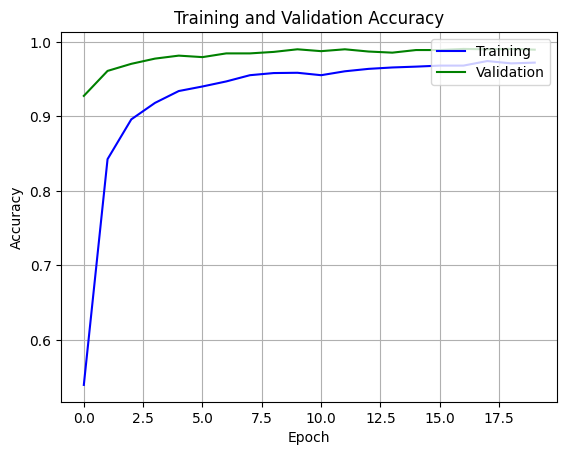

In [21]:
import matplotlib.pyplot as plt


plt.plot(fit_initial_model.history['accuracy'], c="b", label='Train Accuracy')
plt.plot(fit_initial_model.history['val_accuracy'], c="g", label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.savefig('../output/accuracy_plot.png', dpi=150)
plt.show()

### 4. Using the initial model, generate embeddings for the training subset.

In [23]:
import tensorflow as tf

layer_names = [layer.name for layer in initial_model.layers]
print(layer_names)

dense_layers = [layer.name for layer in initial_model.layers 
                if isinstance(layer, tf.keras.layers.Dense)]
print("Available Dense layzers:", dense_layers)
selected_layer = dense_layers[-1]
print(selected_layer)

# _ = model.predict(seed_images_cnn[:1])

['conv2d_2', 'max_pooling2d_2', 'dropout_3', 'conv2d_3', 'max_pooling2d_3', 'dropout_4', 'flatten_1', 'dense_2', 'dropout_5', 'dense_3']
Available Dense layzers: ['dense_2', 'dense_3']
dense_3


In [36]:
import tensorflow as tf

embedding_model = tf.keras.Model(
    inputs=initial_model.inputs, 
    outputs=initial_model.get_layer(selected_layer).output
    ).predict
train_embeddings = embedding_model(
    train_images.reshape(-1,28,28,1)
    )  # shape (60000, 128      )

seed_embeddings = embedding_model(
    seed_images.reshape(-1,28,28,1)
)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


### 5. Project the embeddings onto 2D space, visualize them and automatically cluster them into 10 clusters.

/tmp/ipykernel_57044/2647291875.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


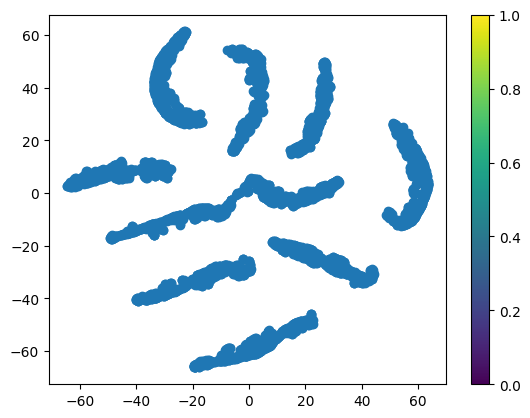

In [37]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2)
embeddings_2d = tsne.fit_transform(
    train_embeddings[:3000]
    )  # Only first n-ones

plt.scatter(
    embeddings_2d[:, 0], 
    embeddings_2d[:, 1], 
    # c=train_labels[:1000], 
    cmap='tab10'
    )
plt.colorbar()
plt.show()


Entrenando KMeans (k=10)...
 Clusters: 10, Ruido: 0, Silueta: 0.5057358145713806, ARI: None


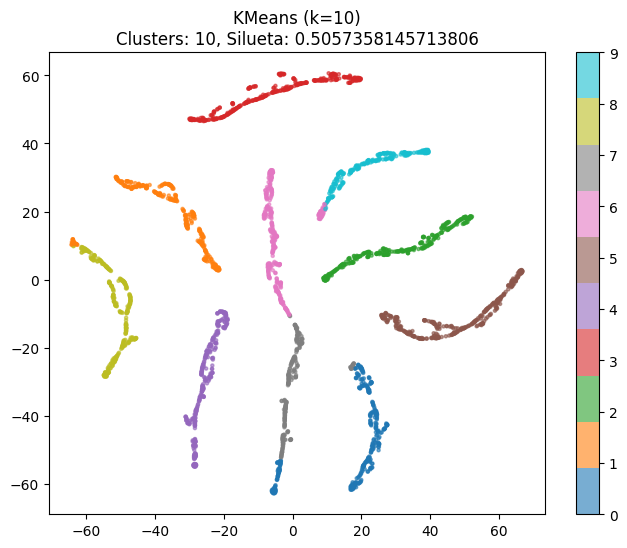

Entrenando DBSCAN (eps=0.5)...
 Clusters: 165, Ruido: 1780, Silueta: -0.28383055329322815, ARI: None


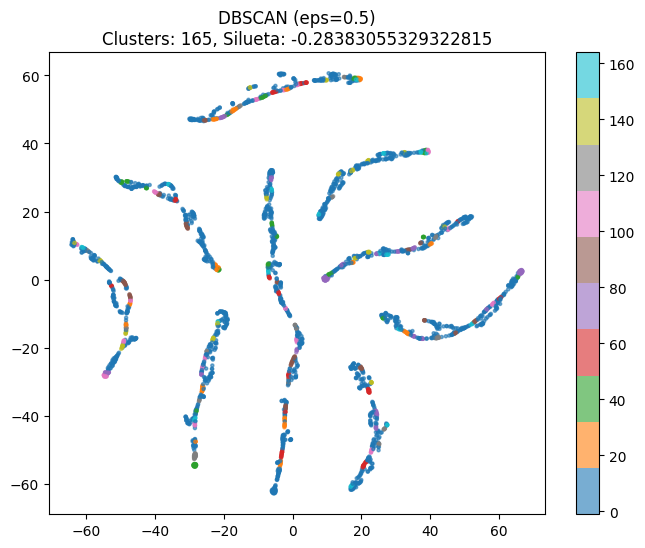

Entrenando DBSCAN (eps=0.7)...
 Clusters: 181, Ruido: 973, Silueta: 0.09414532780647278, ARI: None


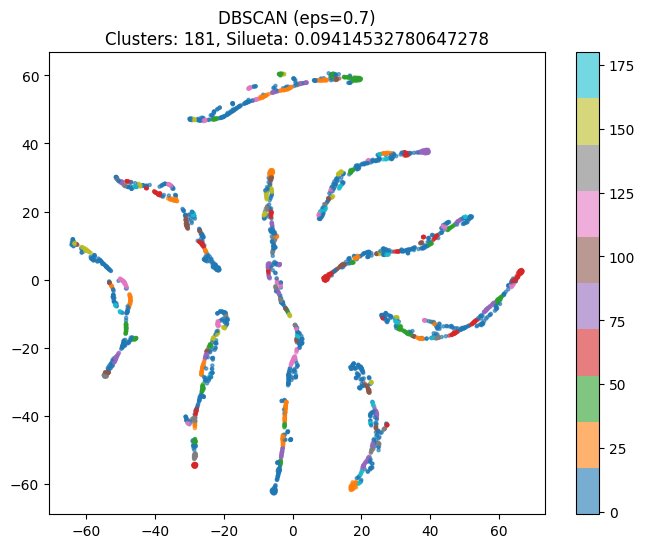

Entrenando Agglomerative (k=10)...
 Clusters: 10, Ruido: 0, Silueta: 0.5132745504379272, ARI: None


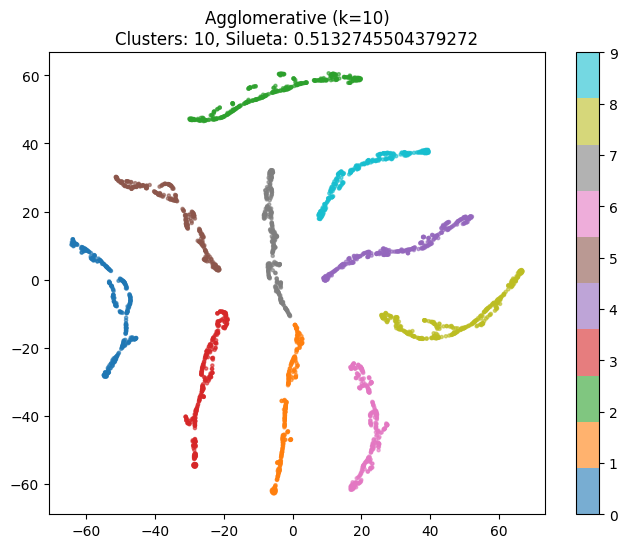

In [38]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
import numpy as np
import matplotlib.pyplot as plt


def evaluate_clustering(
    embeddings, 
    true_labels=None, 
    sample_size=3000
    ):
    """
    Prueba varios algoritmos de clustering sobre los embeddings.
    Muestra métricas y visualiza con t‑SNE (o UMAP).
    """
    # Take a sample
    if embeddings.shape[0] > sample_size:
        indices = np.random.choice(embeddings.shape[0], sample_size, replace=False)
        X_sample = embeddings[indices]
        y_true_sample = true_labels[indices] if true_labels is not None else None
    else:
        X_sample = embeddings
        y_true_sample = true_labels

    # Algorithms to try
    algorithms = {
        'KMeans (k=10)': KMeans(n_clusters=10, random_state=42, n_init=10),
        'DBSCAN (eps=0.5)': DBSCAN(eps=0.5, min_samples=5),
        'DBSCAN (eps=0.7)': DBSCAN(eps=0.7, min_samples=5),
        'Agglomerative (k=10)': AgglomerativeClustering(n_clusters=10),
    }

    # Reduction to visualization (t‑SNE)
    from sklearn.manifold import TSNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_vis = tsne.fit_transform(X_sample)

    results = {}
    for name, model in algorithms.items():
        print(f"Entrenando {name}...")
        labels = model.fit_predict(X_sample)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1) if hasattr(model, 'eps') else 0

        # Metrics
        sil = silhouette_score(X_sample, labels) if n_clusters >= 2 and n_clusters < len(X_sample) else None
        ari = adjusted_rand_score(y_true_sample, labels) if y_true_sample is not None else None

        results[name] = {
            'labels': labels,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'silhouette': sil,
            'ARI': ari
        }
        print(f" Clusters: {n_clusters}, Ruido: {n_noise}, Silueta: {sil}, ARI: {ari}")

        # Visualización
        plt.figure(figsize=(8,6))
        scatter = plt.scatter(X_vis[:,0], X_vis[:,1], c=labels, cmap='tab10', s=5, alpha=0.6)
        plt.colorbar(scatter)
        plt.title(f"{name}\nClusters: {n_clusters}, Silueta: {sil}")
        plt.show()

    return results

result = evaluate_clustering(embeddings=embeddings_2d)


### 6. Determine the classes for the resulting clusters, use them as the initial labels for training samples.


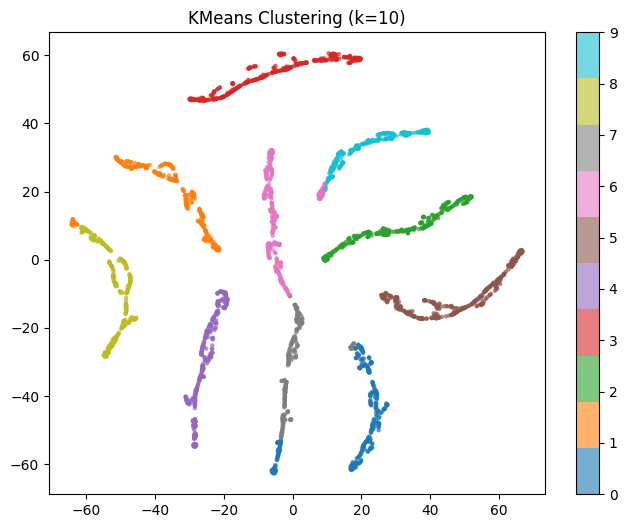

In [43]:
def get_kmeans_labels_and_visualize(
    embeddings, 
    n_clusters=10, 
    sample_size=3000
    ):
    """
    Perform KMeans clustering on full embeddings and visualize a sample.
    Returns cluster labels for the full dataset.
    """
    # Step 1: Cluster the full dataset
    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=42,
        n_init=10
        )
    full_labels = kmeans.fit_predict(embeddings)  # These are your pseudo-labels
    
    # Step 2: Visualize a sample (optional but recommended)
    if embeddings.shape[0] > sample_size:
        indices = np.random.choice(
            embeddings.shape[0], 
            sample_size,
            replace=False
            )
        X_sample = embeddings[indices]
        sample_labels = full_labels[indices]
    else:
        X_sample = embeddings
        sample_labels = full_labels
    
    # Visualize with t-SNE
    tsne = TSNE(
        n_components=2,
        random_state=42,
        perplexity=30
        )
    X_vis = tsne.fit_transform(X_sample)
    
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(X_vis[:,0], X_vis[:,1], c=sample_labels, cmap='tab10', s=5, alpha=0.6)
    plt.colorbar(scatter)
    plt.title(f"KMeans Clustering (k={n_clusters})")
    plt.show()
    
    return full_labels

# Get pseudo-labels for your full dataset
pseudo_labels = get_kmeans_labels_and_visualize(
    embeddings_2d, 
    n_clusters=10
    )

In [ ]:
# Eliminar del pipeline porque usa las train_labels

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import time
import numpy as np
from sklearn.cluster import KMeans

def evaluate_classifiers_for_clustering(
    train_embeddings,
    seed_embeddings,
    seed_labels,
    train_true_labels,
    n_clusters=10
):
    """
    Evalúa distintos clasificadores para asignar clases a clusters.
    Retorna un DataFrame con accuracy y tiempo de entrenamiento.
    """
    classifiers = {
        'Logistic Regression': LogisticRegression(
            max_iter=1000, multi_class='multinomial', solver='lbfgs'
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=100, random_state=42
        ),
        'SVM (RBF)': SVC(
            kernel='rbf', gamma='scale', decision_function_shape='ovo'
        ),
        'SVM (Linear)': SVC(
            kernel='linear', decision_function_shape='ovo'
        ),
        'k-NN (k=5)': KNeighborsClassifier(n_neighbors=5),
        'Decision Tree': DecisionTreeClassifier(random_state=42)
    }

    results = []
    # Clustering the training embeddings
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(train_embeddings)
    cluster_centers = kmeans.cluster_centers_

    for name, clf in classifiers.items():
        start = time.time()
        clf.fit(seed_embeddings, seed_labels)
        cluster_classes = clf.predict(cluster_centers)
        cluster_to_class = {i: int(cluster_classes[i]) for i in range(n_clusters)}
        pseudo_labels = np.array([cluster_to_class[cl] for cl in cluster_labels])
        acc = accuracy_score(train_true_labels, pseudo_labels)
        elapsed = time.time() - start
        results.append({
            'Classifier': name,
            'Accuracy': acc,
            'Time (s)': elapsed
        })
        print(f"{name}: Accuracy={acc:.4f}, Time={elapsed:.2f}s")

    return pd.DataFrame(results)



df_results = evaluate_classifiers_for_clustering(
    train_embeddings,
    seed_embeddings,
    seed_labels,
    train_labels, #groundtruth
    n_clusters=10
)
print("\nResultados completos:")
print(df_results.to_string(index=False))

Logistic Regression: Accuracy=0.9814, Time=0.27s
Random Forest: Accuracy=0.9814, Time=0.96s
SVM (RBF): Accuracy=0.9814, Time=0.05s
SVM (Linear): Accuracy=0.9814, Time=0.04s
k-NN (k=5): Accuracy=0.9814, Time=0.04s
Decision Tree: Accuracy=0.9814, Time=0.07s

Resultados completos:
         Classifier  Accuracy  Time (s)
Logistic Regression  0.981367  0.272406
      Random Forest  0.981367  0.960783
          SVM (RBF)  0.981367  0.050757
       SVM (Linear)  0.981367  0.043129
         k-NN (k=5)  0.981367  0.035388
      Decision Tree  0.981367  0.069871


In [46]:
from sklearn.linear_model import LogisticRegression

def assign_initial_labels(
    train_embeddings,
    seed_embeddings,
    seed_labels,
    n_clusters=10
    ):
    """
    Cluster training embeddings and assign each cluster to a digit class
    using a classifier trained on seed embeddings.
    """
    # 1. Cluster training embeddings
    kmeans = KMeans(
        n_clusters=n_clusters, 
        random_state=42, 
        n_init=10
        )
    cluster_labels = kmeans.fit_predict(train_embeddings)
    cluster_centers = kmeans.cluster_centers_

    # 2. Train embedding classifier on seed set
    clf = LogisticRegression(
        max_iter=1000, 
        multi_class='multinomial',
        solver='lbfgs'
        )
    clf.fit(seed_embeddings, seed_labels)

    # 3. Predict class for each cluster center
    cluster_classes = clf.predict(cluster_centers)

    # 4. Map cluster index to class
    cluster_to_class = {i: 
        int(cluster_classes[i]) 
        for i in range(n_clusters)
        }

    # 5. Assign pseudo-labels to training samples
    pseudo_labels = np.array(
        [
            cluster_to_class[cl]
            for cl in cluster_labels
            ]
        )

    return pseudo_labels, cluster_to_class

pseudo_labels, cluster_to_class = assign_initial_labels(
    train_embeddings, 
    seed_embeddings, 
    seed_labels,
    n_clusters=10
    )


In [50]:
print("Train embeddings shape:", train_embeddings.shape)  # (60000, D)
print("Seed embeddings shape:", seed_embeddings.shape)    # (10000, D)
print("Pseudo labels shape:", pseudo_labels.shape)        # (60000,)

print(pseudo_labels[:10])
print(train_labels[:10])

Train embeddings shape: (60000, 10)
Seed embeddings shape: (10000, 10)
Pseudo labels shape: (60000,)
[5 0 4 1 9 2 1 3 1 4]
[5 0 4 1 9 2 1 3 1 4]


#### From now on you can use the training set to re-train your model, but only with the labels you created, not the groundtruth ones.

### 7. Find the errors in the initial labels in unsupervised fashion, fix them automatically (as much as possible) to create the final set of labels.

In [53]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from collections import Counter


def correct_by_neighbors(
    embeddings,
    labels,
    k=15,
    min_agreement=0.6
    ):
    """
    """
    nbrs = NearestNeighbors(
        n_neighbors=k+1, 
        metric='euclidean'
        ).fit(embeddings)
    distances, indices = nbrs.kneighbors(embeddings) 

    new_labels = labels.copy()
    changes = 0

    for i in range(len(labels)):
        neighbor_indices = indices[i][1:]
        neighbor_labels = labels[neighbor_indices]
        counter = Counter(neighbor_labels)
        most_common_label, count = counter.most_common(1)[0]
        agreement = count / k

        if agreement >= min_agreement and most_common_label != labels[i]:
            new_labels[i] = most_common_label
            changes += 1

    print(f"Neighboors: {changes} changed labels (from {len(labels)})")
    return new_labels

pseudo_labels_corrected = correct_by_neighbors(
    train_embeddings,
    pseudo_labels,
    k=15, 
    min_agreement=0.6
    )

acc_after_neighbors = accuracy_score(
    train_labels,
    pseudo_labels_corrected
    )
print(f"Accuracy after correcting by neighboors: {acc_after_neighbors:.4f}")


def self_training(
    embeddings,
    labels,
    clf=None,
    max_iter=3,
    threshold=0.9
    ):
    """
    """
    if clf is None:
        clf = LogisticRegression(
            max_iter=1000,
            multi_class='multinomial',
            solver='lbfgs'
            )

    current_labels = labels.copy()
    total_changes = 0

    for iteration in range(max_iter):
        clf.fit(
            embeddings,
            current_labels
            )
        probs = clf.predict_proba(
            embeddings
            )
        preds = clf.predict(
            embeddings
            )
        max_probs = np.max(
            probs,
            axis=1
            )
        high_conf = max_probs > threshold
        changes = (
            preds != current_labels
            ) & high_conf
        current_labels[changes] = preds[changes]
        n_changes = np.sum(changes)
        total_changes += n_changes
        print(f"Iteration {iteration+1}: {n_changes} changes")

        if n_changes == 0:
            break

    print(f"Self‑training total: {total_changes} accumulated changes")
    return current_labels



# =========
pseudo_labels_final = self_training(
    train_embeddings,
    pseudo_labels_corrected,
    max_iter=3,
    threshold=0.9
)

# Evaluación final con ground truth
acc_final = accuracy_score(
    train_labels,
    pseudo_labels_final
    )
print(f"\nCombined (final) accuracy: {acc_final:.4f}")

# Mostrar resumen de cambios
print("\nSummary of corrections:")
print(f"  - Initial labels:                        {accuracy_score(train_labels, pseudo_labels):.4f}")
print(f"  - After neighboors:                      {acc_after_neighbors:.4f}")
print(f"  - After self‑training (final accuracy):  {acc_final:.4f}")

Neighboors: 16 changed labels (from 60000)
Accuracy after correcting by neighboors: 0.9816
Iteration 1: 0 changes
Self‑training total: 0 accumulated changes

Combined (final) accuracy: 0.9816

Summary of corrections:
  - Initial labels:                        0.9814
  - After neighboors:                      0.9816
  - After self‑training (final accuracy):  0.9816
